### Roles To Explore:

In [2]:
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

#Loading_data
dataset = load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#Data_Cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df[df['job_skills'].notna()]['job_skills'].apply(ast.literal_eval)


In [3]:
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()


<Axes: xlabel='count', ylabel='job_location'>

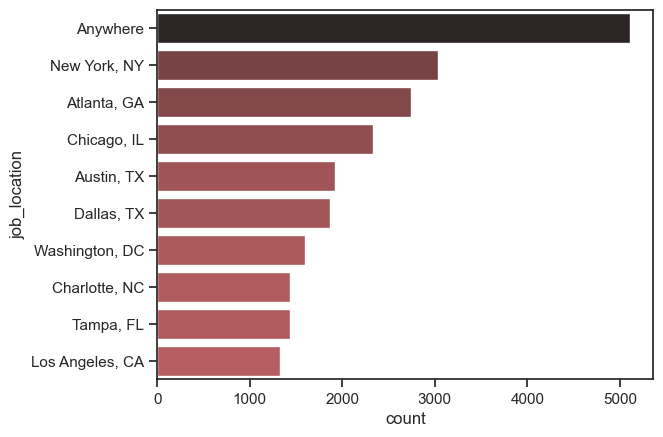

In [ ]:
df_plot=df_DA_US['job_location'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(df_plot,x='count',y='job_location',hue='count',palette='dark:r_r',legend=False)


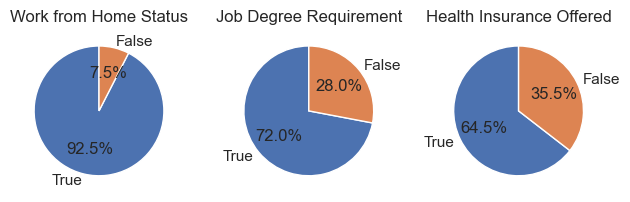

In [23]:
fig , ax=plt.subplots(1,3)
dict_columns={'job_work_from_home': 'Work from Home Status', 
              'job_no_degree_mention': 'Job Degree Requirement',
              'job_health_insurance': 'Health Insurance Offered'}

for i,(column,title) in enumerate(dict_columns.items()):
    ax[i].pie(df_DA_US[column].value_counts(), startangle=90, autopct='%1.1f%%', labels=[True, False]) #startangle bach nbdlo l orientation dyal chart
    ax[i].set_title(title)

fig.tight_layout()
plt.show()

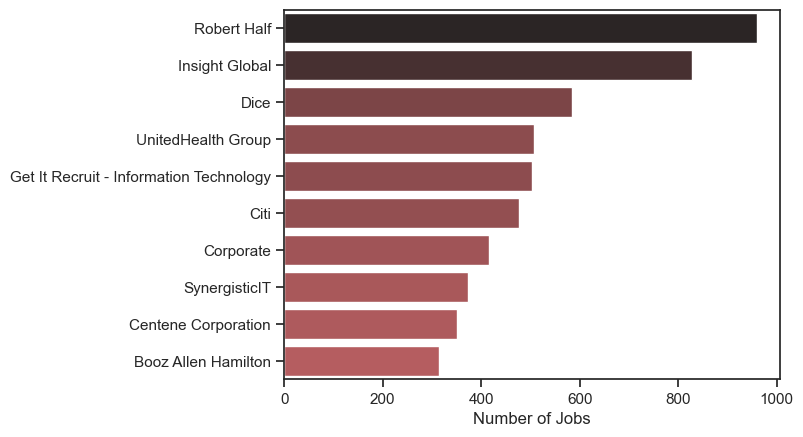

In [28]:
df_plot=df_DA_US['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')
sns.barplot(df_plot,x='count',y='company_name',hue='count',palette='dark:r_r',legend=False)
plt.ylabel('')
plt.xlabel('Number of Jobs')
plt.show()